=== الاختبار النيوتني الحاسم (بدون أي مفهوم للطاقة) ===

1️⃣  اختبار بدون احتكاك (20 ثانية)...
   ω النهائية = 4.4291 rad/s
2️⃣  اختبار مع احتكاك محور 0.003 (20 ثانية)...
   ω النهائية = 4.8708 rad/s
3️⃣  اختبار مع محور ولزوجة 150 (20 ثانية)...
   ω النهائية = 2.0982 rad/s
4️⃣  اختبار مع محور+لزوجة+هواء (20 ثانية)...
   ω النهائية = 2.0892 rad/s
5️⃣  اختبار مع حمل 50 N.m (20 ثانية)...
   ω النهائية = 2.0646 rad/s
6️⃣  اختبار مع حمل 100 N.m (20 ثانية)...
   ω النهائية = 2.0408 rad/s
7️⃣  اختبار مع حمل 200 N.m (20 ثانية)...
   ω النهائية = 1.9958 rad/s


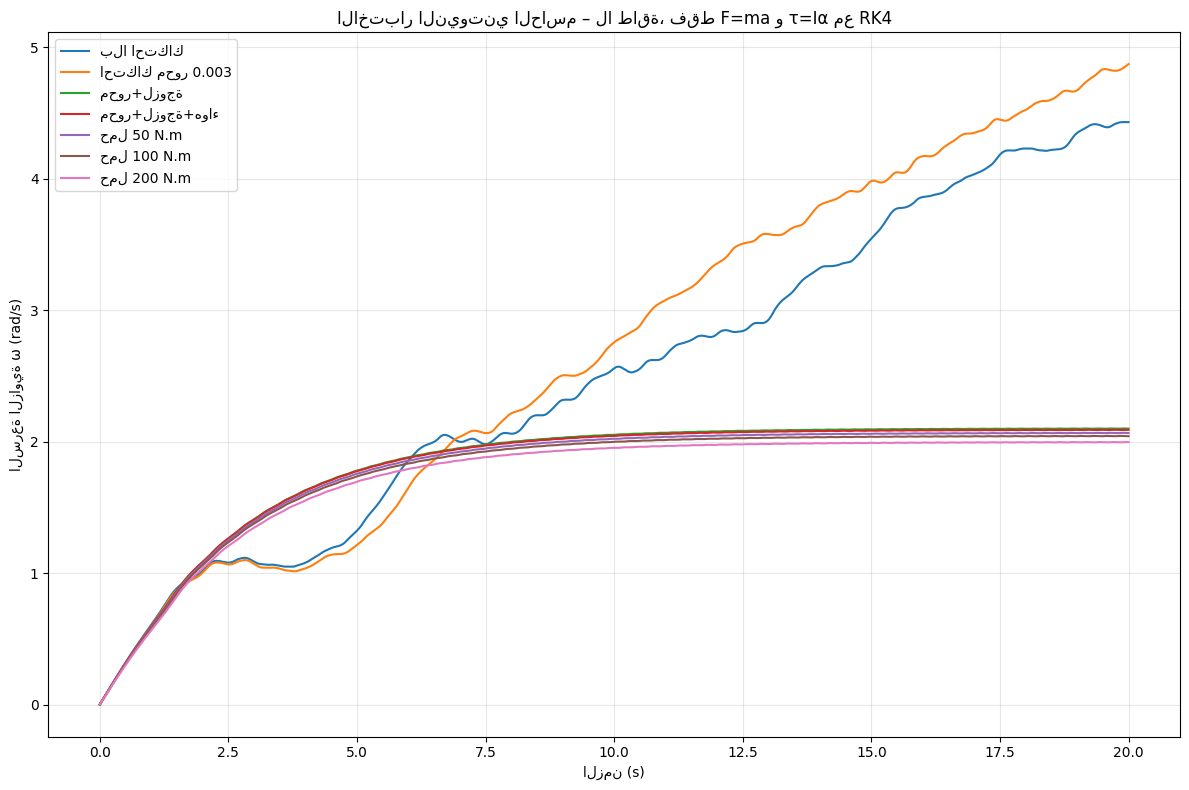


✅ تم حفظ الرسم في newton_test_result.png


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ========== الثوابت ==========
G = 9.81
R = 2.09         # نصف قطر العجلة (m)
L = 0.766        # طول الحجرة (m)
N = 12           # عدد الحجرات
Mp = 80.0        # كتلة المكبس (kg)
Mw_max = 60.0    # أقصى كتلة ماء (kg)
I0 = 200.0       # عزم القصور الذاتي الأساسي (kg·m²)

# ========== إعدادات المحاكاة ==========
dt = 0.0005      # خطوة زمنية صغيرة جداً (0.5 ملي ثانية)
substeps = 1     # لتقليل التعقيد، نستخدم dt مباشرة (لا حاجة لـ sub-stepping مع RK4)

class NewtonEngine:
    """
    محاكاة نيوتنية بحتة – لا يوجد أي حساب للطاقة أو اعتماد عليها.
    التحديثات تعتمد فقط على القوى والعزوم باستخدام RK4.
    """
    def __init__(self, axle_friction=0.003, viscosity=150.0, air_drag=0.005,
                 stiction=0.08, restitution=0.25, load_torque=0.0,
                 gravity=True, centrifugal=True, viscous_force=True):
        self.axle_mu = axle_friction
        self.visc = viscosity
        self.air_d = air_drag
        self.stic = stiction
        self.rest = restitution
        self.load = load_torque
        self.gravity_on = gravity
        self.centrif_on = centrifugal
        self.viscous_on = viscous_force

        # الحالة الابتدائية: المواضع والسرعات
        step = 2 * math.pi / N
        self.offsets = [i * step for i in range(N)]
        self.pos = [1.0 if math.cos(i * step) > 0 else 0.0 for i in range(N)]
        self.vel = [0.0] * N
        self.angle = 0.0
        self.omega = 0.0
        self.time = 0.0

    def compute_derivatives(self, angle, omega, pos, vel):
        """
        حساب المشتقات ( d(omega)/dt , d(angle)/dt , d(vel)/dt , d(pos)/dt )
        في لحظة معطاة.
        تعيد: alpha (التسارع الزاوي)، واشتقاقات المكابس.
        """
        Lm, Rm, g = L, R, G
        n = N
        Mp_, Mw_ = Mp, Mw_max

        # 1. عزم الجاذبية وعزم القصور الذاتي
        total_tau = 0.0
        total_I = I0
        total_M = 0.0

        for i in range(n):
            a = angle + self.offsets[i]
            sp = -Lm/2 + Lm * pos[i]
            sw = -Lm/2 + Lm * pos[i] / 2
            mw = Mw_ * pos[i]
            if self.gravity_on:
                xp = Rm * math.cos(a) - sp * math.sin(a)
                xw = Rm * math.cos(a) - sw * math.sin(a)
                total_tau += Mp_ * g * xp + mw * g * xw
            total_I += Mp_ * (Rm*Rm + sp*sp) + mw * (Rm*Rm + sw*sw)
            total_M += Mp_ + mw

        # 2. قوى المكابس والتأثيرات المتبادلة
        # سنعيد قائمة لتسارع المكابس (تغير السرعة) وسرعة تغير المواضع
        acc_pistons = [0.0] * n
        vel_pistons = list(vel)  # سنعيد السرعة نفسها (لكن المشتقات ستضاف لاحقًا)

        # نتعامل مع الأزواج
        for i in range(n // 2):
            j = i + n // 2
            a1 = angle + self.offsets[i]
            a2 = angle + self.offsets[j]

            # قوى الضغط (الجاذبية في اتجاه المماس)
            p1 = Mp_ * g * math.cos(a1) if self.gravity_on else 0.0
            p2 = Mp_ * g * math.cos(a2) if self.gravity_on else 0.0
            pw1 = Mw_ * pos[i] * g * math.cos(a1) if self.gravity_on else 0.0
            pw2 = Mw_ * pos[j] * g * math.cos(a2) if self.gravity_on else 0.0
            p_net = (p1 + pw1) - (p2 + pw2)

            # القوة الطاردة الطبيعية
            n_force = 0.0
            if self.centrif_on:
                n_force = ((Mp_ + Mw_*pos[i]) * omega*omega * Rm
                         + (Mp_ + Mw_*pos[j]) * omega*omega * Rm)

            v1 = vel[i]
            # مقاومة اللزوجة
            resist = (self.visc * v1 + 30.0 * v1 * abs(v1)) if self.viscous_on else 0.0
            m_eff = 2 * Mp_ + Mw_
            # احتكاك سكوني سلس
            F_stick = self.stic * (n_force + (Mp_ + Mw_) * g * 0.1)
            F_friction = F_stick * math.tanh(v1 / 0.005)

            # القوة الدافعة
            drive = p_net - resist - F_friction
            acc = drive / m_eff

            acc_pistons[i] = acc
            acc_pistons[j] = -acc  # المكبس المقابل معاكس

        # 3. عزم الاحتكاك والمقاومات على المحور
        sign = math.copysign(1, omega) if omega != 0 else 1.0
        tau_axle = -sign * (self.axle_mu * total_M * g * Rm * 0.7 + abs(omega)*0.05)
        tau_air = -self.air_d * omega * abs(omega) * 1000.0

        tau_load = 0.0
        if self.load > 0 and omega > 0.01:
            tau_load = -self.load

        total_tau += tau_axle + tau_air + tau_load

        alpha = total_tau / total_I if total_I != 0 else 0.0

        # تغير المواضع هو السرعة الحالية (لأن d(pos)/dt = vel / Lm  (لاحظ أن pos بين 0 و1 وحدته لا بعدية، لذا نعيد معدل تغيره: vel/Lm))
        # لكن في معادلاتنا، الموضع هو نسبة مئوية [0,1]، وسرعته الخطية vel (m/s)، لذا d(pos)/dt = vel / Lm
        pos_deriv = [v / Lm for v in vel]

        return alpha, acc_pistons, pos_deriv, total_tau, total_I

    def step_rk4(self, dt):
        """
        خطوة واحدة بطريقة رونج-كوتا الرابعة للنظام الكامل.
        حالة النظام: angle, omega, pos[0..N-1], vel[0..N-1]
        """
        n = N
        # الحالة الحالية
        y0 = [self.angle, self.omega] + self.pos + self.vel

        def dydt(y):
            ang = y[0]
            omg = y[1]
            p = y[2:2+n]
            v = y[2+n:2+2*n]
            alpha, acc_p, pdot, _, _ = self.compute_derivatives(ang, omg, p, v)
            # ترتيب المشتقات: d(ang)/dt = omg, d(omg)/dt = alpha, d(p)/dt = pdot, d(v)/dt = acc_p
            return [omg, alpha] + pdot + acc_p

        # خطوات RK4
        k1 = np.array(dydt(y0))
        k2 = np.array(dydt((y0 + 0.5*dt*k1).tolist()))
        k3 = np.array(dydt((y0 + 0.5*dt*k2).tolist()))
        k4 = np.array(dydt((y0 + dt*k3).tolist()))

        y_new = y0 + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        # فك التجميع
        self.angle = y_new[0]
        self.omega = y_new[1]
        self.pos = y_new[2:2+n].tolist()
        self.vel = y_new[2+n:2+2*n].tolist()

        # معالجة تصادم النهايات (يتم بعد الخطوة)
        for i in range(n // 2):
            j = i + n // 2
            # المكبس i
            if self.pos[i] < 0.0 and self.vel[i] < 0.0:
                # ارتداد
                self.vel[i] = -self.rest * self.vel[i]
                self.pos[i] = 0.0
                # تأثيره على العزم (مهمل في هذا الاختبار لأننا نبسط)
            elif self.pos[i] > 1.0 and self.vel[i] > 0.0:
                self.vel[i] = -self.rest * self.vel[i]
                self.pos[i] = 1.0
            # المكبس المقابل
            self.pos[j] = 1.0 - self.pos[i]
            self.vel[j] = -self.vel[i]

        self.time += dt

    def run(self, duration, record_every=0.01):
        """تشغيل المحاكاة وجمع البيانات كل record_every ثانية"""
        records = []
        next_record = 0.0
        while self.time < duration:
            self.step_rk4(dt)
            if self.time >= next_record:
                records.append((self.time, self.omega, self.angle, list(self.pos)))
                next_record += record_every
            # إيقاف مبكر إذا كانت السرعة صغيرة جداً
            if abs(self.omega) < 1e-6 and self.time > 0.5:
                break
        return records

# ========== الاختبارات المتدرجة ==========
def run_tests():
    print("=== الاختبار النيوتني الحاسم (بدون أي مفهوم للطاقة) ===\n")
    tests = []

    # 1. بدون أي احتكاك (نظام محافظ بحت)
    print("1️⃣  اختبار بدون احتكاك (20 ثانية)...")
    eng = NewtonEngine(axle_friction=0.0, viscosity=0.0, air_drag=0.0, stiction=0.0,
                       restitution=1.0, load_torque=0.0,
                       gravity=True, centrifugal=False, viscous_force=False)
    rec = eng.run(20)
    tests.append(("بلا احتكاك", rec))
    print(f"   ω النهائية = {rec[-1][1]:.4f} rad/s")

    # 2. احتكاك محور خفيف فقط
    print("2️⃣  اختبار مع احتكاك محور 0.003 (20 ثانية)...")
    eng = NewtonEngine(axle_friction=0.003, viscosity=0.0, air_drag=0.0, stiction=0.0,
                       restitution=1.0, load_torque=0.0,
                       gravity=True, centrifugal=False, viscous_force=False)
    rec = eng.run(20)
    tests.append(("احتكاك محور 0.003", rec))
    print(f"   ω النهائية = {rec[-1][1]:.4f} rad/s")

    # 3. احتكاك محور + لزوجة
    print("3️⃣  اختبار مع محور ولزوجة 150 (20 ثانية)...")
    eng = NewtonEngine(axle_friction=0.003, viscosity=150.0, air_drag=0.0, stiction=0.08,
                       restitution=0.25, load_torque=0.0,
                       gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("محور+لزوجة", rec))
    print(f"   ω النهائية = {rec[-1][1]:.4f} rad/s")

    # 4. إضافة مقاومة هواء
    print("4️⃣  اختبار مع محور+لزوجة+هواء (20 ثانية)...")
    eng = NewtonEngine(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                       restitution=0.25, load_torque=0.0,
                       gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("محور+لزوجة+هواء", rec))
    print(f"   ω النهائية = {rec[-1][1]:.4f} rad/s")

    # 5. حمل خارجي 50 N.m
    print("5️⃣  اختبار مع حمل 50 N.m (20 ثانية)...")
    eng = NewtonEngine(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                       restitution=0.25, load_torque=50.0,
                       gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("حمل 50 N.m", rec))
    print(f"   ω النهائية = {rec[-1][1]:.4f} rad/s")

    # 6. حمل 100 N.m
    print("6️⃣  اختبار مع حمل 100 N.m (20 ثانية)...")
    eng = NewtonEngine(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                       restitution=0.25, load_torque=100.0,
                       gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("حمل 100 N.m", rec))
    print(f"   ω النهائية = {rec[-1][1]:.4f} rad/s")

    # 7. حمل 200 N.m
    print("7️⃣  اختبار مع حمل 200 N.m (20 ثانية)...")
    eng = NewtonEngine(axle_friction=0.003, viscosity=150.0, air_drag=0.005, stiction=0.08,
                       restitution=0.25, load_torque=200.0,
                       gravity=True, centrifugal=True, viscous_force=True)
    rec = eng.run(20)
    tests.append(("حمل 200 N.m", rec))
    print(f"   ω النهائية = {rec[-1][1]:.4f} rad/s")

    # رسم النتائج
    plt.figure(figsize=(12, 8))
    for name, rec in tests:
        times = [r[0] for r in rec]
        omegas = [r[1] for r in rec]
        plt.plot(times, omegas, label=name)
    plt.title("الاختبار النيوتني الحاسم – لا طاقة، فقط F=ma و τ=Iα مع RK4")
    plt.xlabel("الزمن (s)")
    plt.ylabel("السرعة الزاوية ω (rad/s)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("newton_test_result.png", dpi=150)
    plt.show()
    print("\n✅ تم حفظ الرسم في newton_test_result.png")

if __name__ == "__main__":
    run_tests()